In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [3]:
df = pd.read_csv("openings.csv")
print("Данные загружены успешно!")
print(f"Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()

Данные загружены успешно!
Размер: 1884 строк, 26 столбцов


,Unnamed: 0,Opening,Colour,Num Games,ECO,Last Played,Perf Rating,Avg Player,Player Win %,Draw %,...,move2b,move3w,move3b,move4w,move4b,White_win%,Black_win%,White_odds,White_Wins,Black_Wins
0,0,"Alekhine Defense, Balogh Variation",white,692,B03,2018-06-22,2247,2225,40.8,24.3,...,Nd5,d4,d6,Bc4,NaN,40.8,35.0,1.165714,282.336,242.200
1,1,"Alekhine Defense, Brooklyn Variation",black,228,B02,2018-06-27,2145,2193,29.8,22.4,...,Ng8,NaN,NaN,NaN,NaN,47.8,29.8,1.604027,108.984,67.944
2,2,"Alekhine Defense, Exchange Variation",white,6485,B03,2018-07-06,2244,2194,40.8,27.7,...,Nd5,d4,d6,c4,Nb6,40.8,31.5,1.295238,2645.880,2042.775
3,3,"Alekhine Defense, Four Pawns Attack",white,881,B03,2018-06-20,2187,2130,39.7,23.2,...,Nd5,d4,d6,c4,Nb6,39.7,37.1,1.070081,349.757,326.851
4,4,"Alekhine Defense, Four Pawns Attack, Fianchett...",black,259,B03,2018-05-20,2122,2178,37.8,21.2,...,Nd5,d4,d6,c4,Nb6,40.9,37.8,1.082011,105.931,97.902


In [4]:
print("=== Размер датасета ===")
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")

print("\n=== Типы данных ===")
print(df.dtypes)

print("\n=== Пропуски по колонкам ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Пропусков': missing,
    '% от всех': missing_pct
}).query('Пропусков > 0')

if missing_df.empty:
    print("Пропусков нет!")
else:
    print(missing_df)
    # Удаляем строки с пропусками
    before = df.shape[0]
    df = df.dropna()
    print(f"\nУдалено строк: {before - df.shape[0]}")
    print(f"Итоговый размер: {df.shape}")

print("\n=== Описательная статистика ===")
df.describe()

=== Размер датасета ===
Строк: 1884, Столбцов: 26

=== Типы данных ===
Unnamed: 0          int64
Opening               str
Colour                str
Num Games           int64
ECO                   str
Last Played           str
Perf Rating         int64
Avg Player          int64
Player Win %      float64
Draw %            float64
Opponent Win %    float64
Moves                 str
moves_list            str
move1w                str
move1b                str
move2w                str
move2b                str
move3w                str
move3b                str
move4w                str
move4b                str
White_win%        float64
Black_win%        float64
White_odds        float64
White_Wins        float64
Black_Wins        float64
dtype: object

=== Пропуски по колонкам ===
        Пропусков  % от всех
move1b         15       0.80
move2w         70       3.72
move2b        140       7.43
move3w        256      13.59
move3b        383      20.33
move4w        544      28.87
move4b

,Unnamed: 0,Num Games,Perf Rating,Avg Player,Player Win %,Draw %,Opponent Win %,White_win%,Black_win%,White_odds,White_Wins,Black_Wins
count,1186.000000,1186.000000,1186.000000,1186.000000,1186.000000,1186.000000,1186.000000,1186.000000,1186.000000,1186.000000,1186.000000,1186.000000
mean,994.055649,1492.163575,2270.778246,2272.018550,34.234570,31.801096,33.964924,39.224283,28.975211,1.499703,570.803807,429.629394
std,532.638119,2044.604935,123.795853,114.363982,9.322301,8.408386,9.216050,7.490183,7.950369,0.675070,784.656038,620.264976
min,2.000000,100.000000,1626.000000,1606.000000,7.500000,5.800000,6.700000,13.600000,6.700000,0.330017,23.000000,8.946000
25%,537.250000,296.750000,2208.000000,2213.000000,27.225000,26.100000,27.900000,34.200000,23.600000,1.067520,118.105000,80.890000
50%,1039.000000,706.500000,2284.000000,2288.000000,33.800000,31.400000,33.750000,38.800000,28.500000,1.373264,269.655500,199.006000
75%,1459.000000,1850.500000,2355.000000,2351.000000,40.775000,37.100000,39.775000,43.800000,33.575000,1.758639,687.552000,502.372500
max,1883.000000,15992.000000,2536.000000,2492.000000,77.600000,68.500000,69.800000,77.600000,61.800000,8.718310,6044.976000,5997.000000


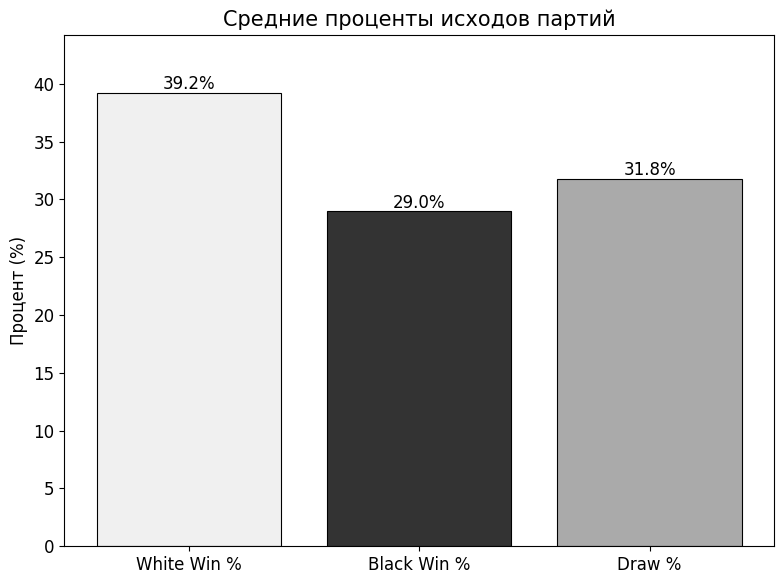

In [5]:
# Средние значения побед белых, чёрных и ничьих
means = {
    'White Win %': df['White_win%'].mean(),
    'Black Win %': df['Black_win%'].mean(),
    'Draw %':      df['Draw %'].mean()
}

plt.figure(figsize=(8, 6))
bars = plt.bar(means.keys(), means.values(),
               color=['#f0f0f0', '#333333', '#aaaaaa'],
               edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, means.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=12)

plt.title("Средние проценты исходов партий", fontsize=15)
plt.ylabel("Процент (%)")
plt.ylim(0, max(means.values()) + 5)
plt.tight_layout()
plt.savefig("win_distribution.png", dpi=150)
plt.show()

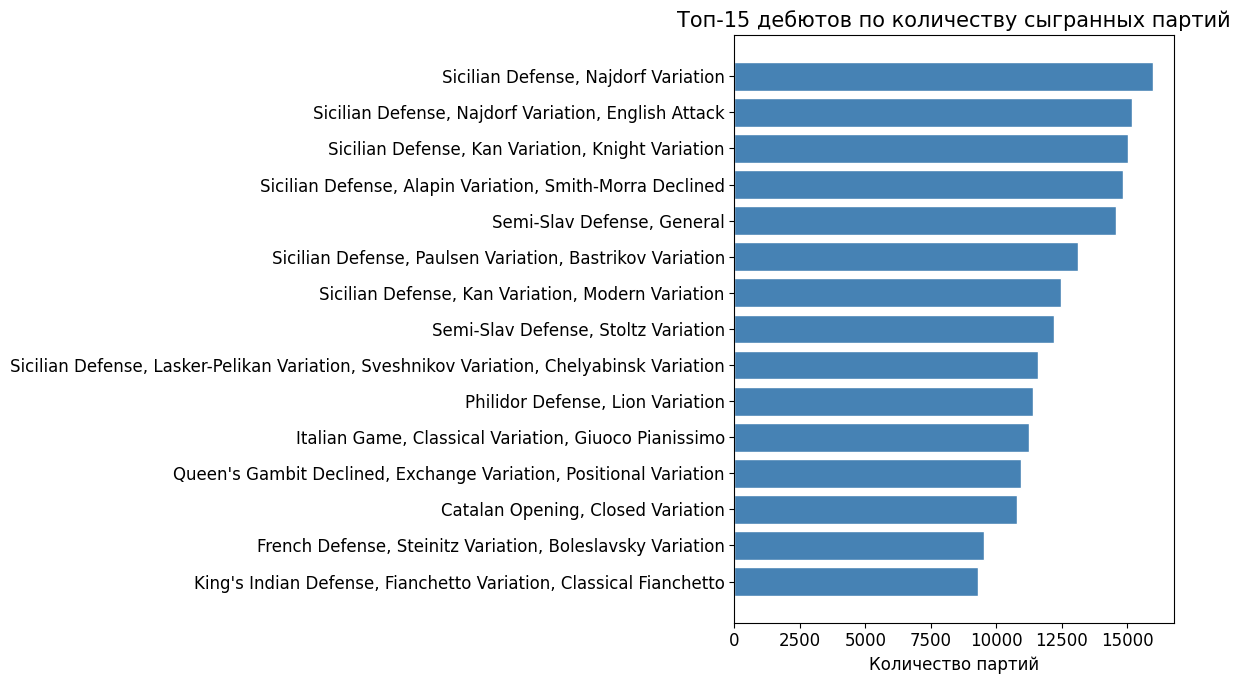

In [6]:
top15 = df.nlargest(15, 'Num Games')[['Opening', 'Num Games']]

plt.figure(figsize=(12, 7))
bars = plt.barh(top15['Opening'], top15['Num Games'],
                color='steelblue', edgecolor='white')

plt.xlabel("Количество партий")
plt.title("Топ-15 дебютов по количеству сыгранных партий", fontsize=15)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top15_openings.png", dpi=150)
plt.show()

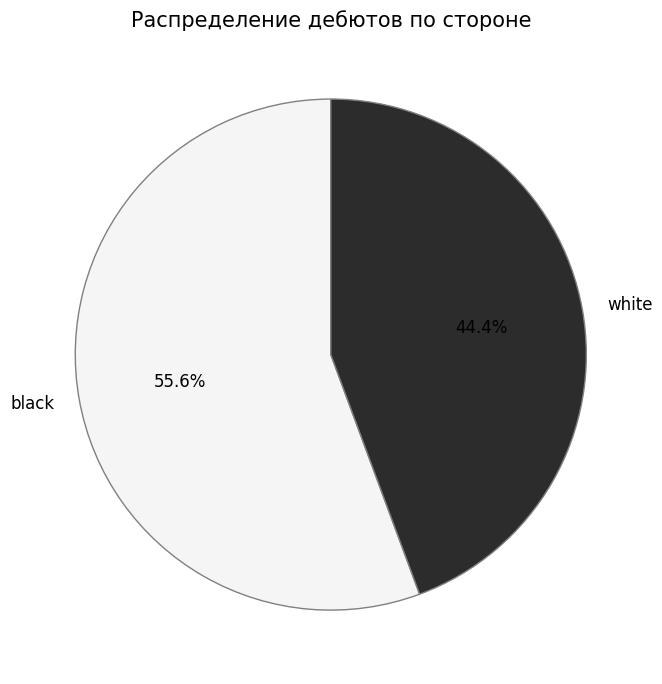

In [7]:
colour_counts = df['Colour'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(colour_counts.values,
        labels=colour_counts.index,
        autopct='%1.1f%%',
        colors=['#f5f5f5', '#2c2c2c'],
        startangle=90,
        wedgeprops={'edgecolor': 'gray', 'linewidth': 1})
plt.title("Распределение дебютов по стороне", fontsize=15)
plt.tight_layout()
plt.savefig("colour_pie.png", dpi=150)
plt.show()

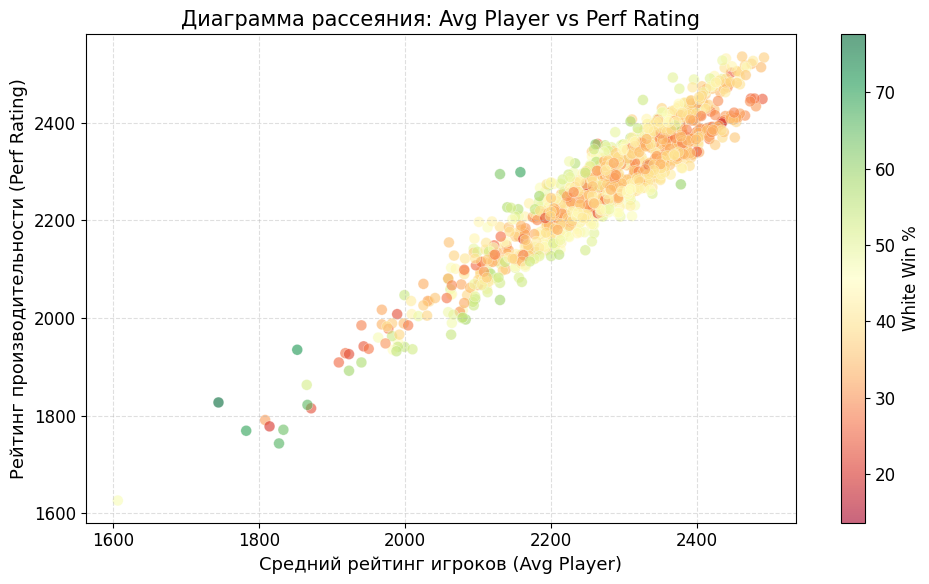

In [8]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['Avg Player'],
    df['Perf Rating'],
    c=df['White_win%'],
    cmap='RdYlGn',
    alpha=0.6,
    edgecolors='white',
    linewidths=0.3,
    s=60
)
plt.colorbar(scatter, label='White Win %')
plt.xlabel("Средний рейтинг игроков (Avg Player)", fontsize=13)
plt.ylabel("Рейтинг производительности (Perf Rating)", fontsize=13)
plt.title("Диаграмма рассеяния: Avg Player vs Perf Rating", fontsize=15)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("scatter.png", dpi=150)
plt.show()

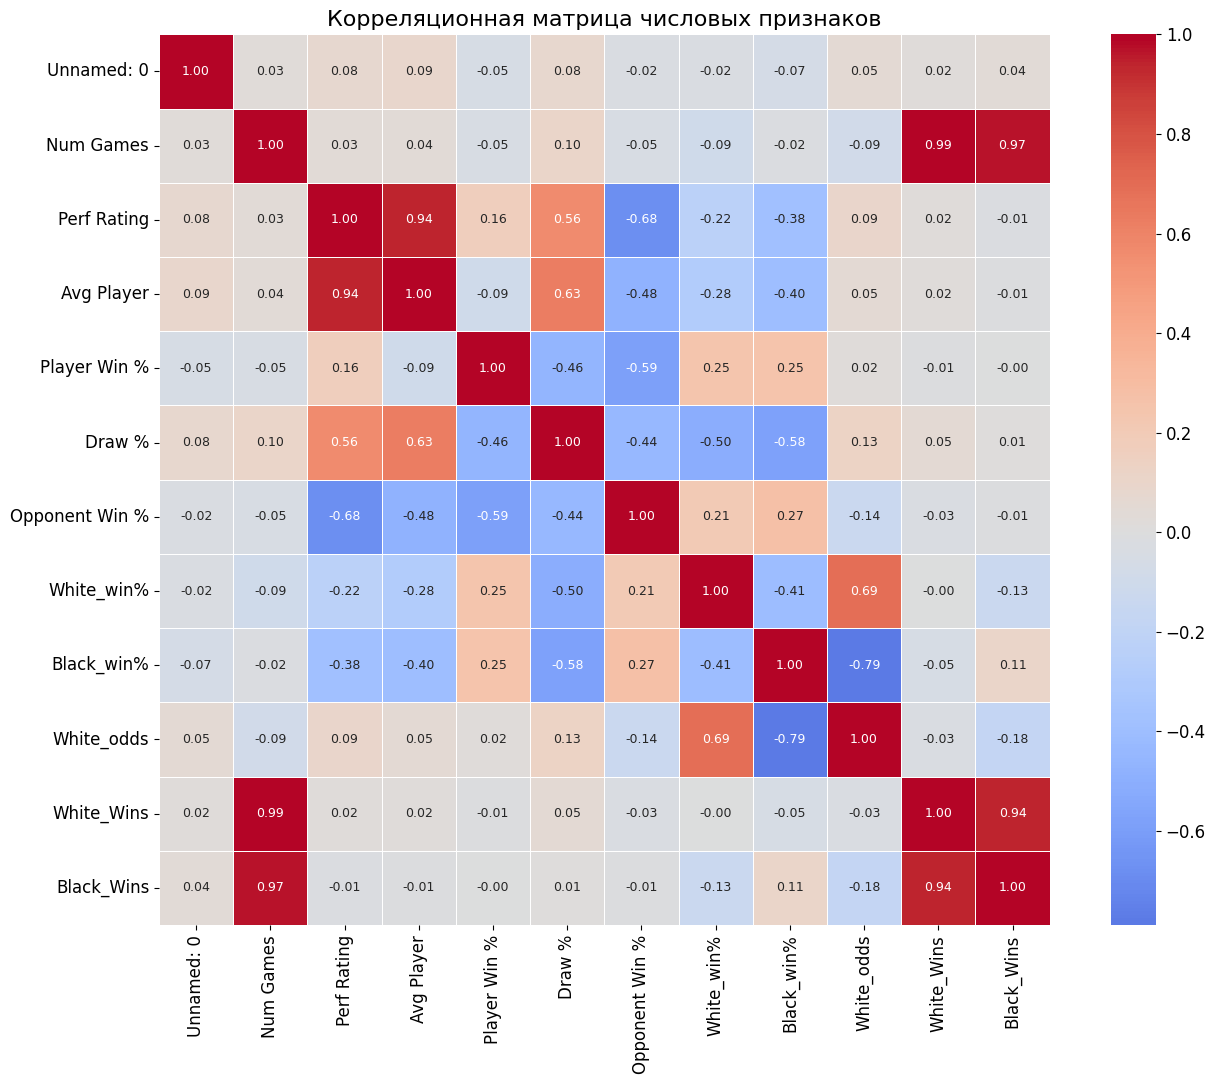

In [9]:
# Только числовые колонки
numeric_df = df.select_dtypes(include=[np.number])

corr = numeric_df.corr()

plt.figure(figsize=(14, 11))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title("Корреляционная матрица числовых признаков", fontsize=16)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

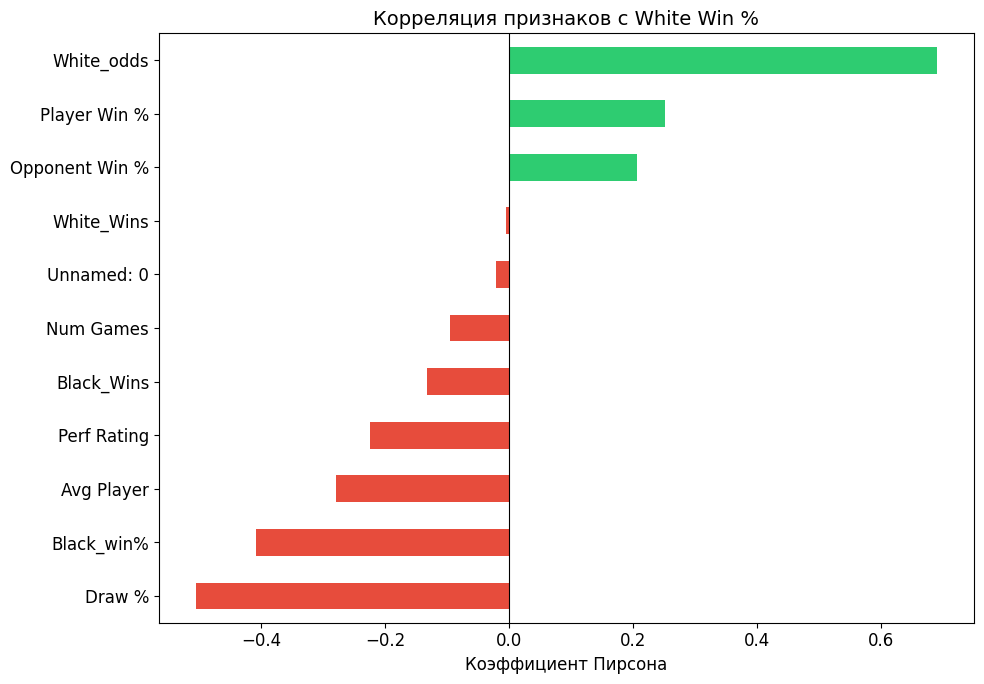

In [10]:
target_corr = corr["White_win%"].drop("White_win%").sort_values()
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr]

plt.figure(figsize=(10, 7))
target_corr.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Корреляция признаков с White Win %", fontsize=14)
plt.xlabel("Коэффициент Пирсона")
plt.tight_layout()
plt.savefig("target_corr.png", dpi=150)
plt.show()